In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/playground-series-s5e1/sample_submission.csv
/kaggle/input/playground-series-s5e1/train.csv
/kaggle/input/playground-series-s5e1/test.csv
/kaggle/input/datasets/davibaca/study-xgb/permutation_result.pkl
/kaggle/input/datasets/davibaca/study-xgb/model_xgb.pkl
/kaggle/input/datasets/davibaca/study-xgb/study_xgb_target.pkl
/kaggle/input/datasets/davibaca/study-xgb/study_xgb_onehot.pkl
/kaggle/input/datasets/davibaca/study-xgb/study_xgb (1).pkl


In [2]:
!pip install -U optuna
import optuna
print(optuna.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 11.3 MB/s eta 0:00:00
  Attempting uninstall: optuna
    Found existing installation: optuna 4.1.0
    Uninstalling optuna-4.1.0:
      Successfully uninstalled optuna-4.1.0
5.0.0


In [3]:
!pip install -U scikit-learn
import sklearn
print(sklearn.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 77.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
1.7.2


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
color_pal = sns.color_palette()

In [5]:
# Create functions

# Time series features
def create_features(df):
    df = df.copy()
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week
    return df


In [6]:
# DataFrame with training data
train_df = pd.read_csv('/kaggle/input/playground-series-s5e1/train.csv', parse_dates=["date"])
train_df.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


In [7]:
# DataFrame with testing data
test_df = pd.read_csv('/kaggle/input/playground-series-s5e1/test.csv',parse_dates=["date"])
test_df.head()


,id,date,country,store,product
0,230130,2017-01-01,Canada,Discount Stickers,Holographic Goose
1,230131,2017-01-01,Canada,Discount Stickers,Kaggle
2,230132,2017-01-01,Canada,Discount Stickers,Kaggle Tiers
3,230133,2017-01-01,Canada,Discount Stickers,Kerneler
4,230134,2017-01-01,Canada,Discount Stickers,Kerneler Dark Mode


# Data analysis

In [8]:
#Type of variables
train_df.dtypes

id                   int64
date        datetime64[ns]
country             object
store               object
product             object
num_sold           float64
dtype: object

Three variables type object, one type date time. Dependent variable type numeric

In [9]:
train_df["country"].value_counts()

country
Canada       38355
Finland      38355
Italy        38355
Kenya        38355
Norway       38355
Singapore    38355
Name: count, dtype: int64

In [10]:
train_df.groupby('country')['num_sold'].sum()

country
Canada       28653095.0
Finland      28698872.0
Italy        20797669.0
Kenya          689141.0
Norway       54562305.0
Singapore    33102374.0
Name: num_sold, dtype: float64

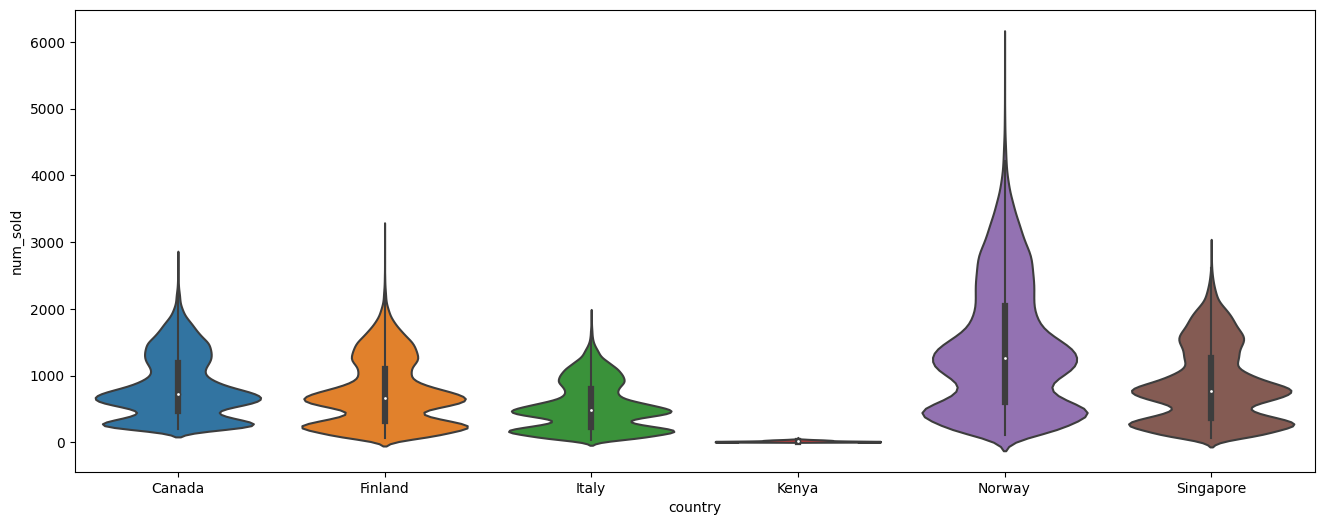

In [11]:
plt.figure(figsize=(16, 6))

sns.violinplot(x='country', y='num_sold', data=train_df, scale='width')

plt.show()

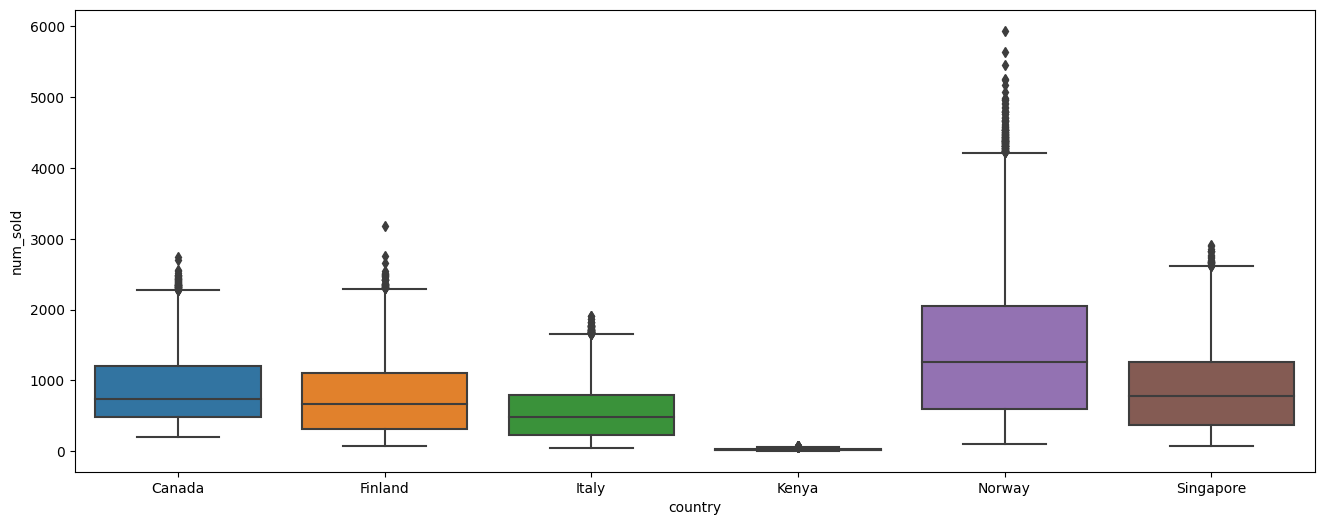

In [12]:
plt.figure(figsize=(16, 6))

sns.boxplot(x='country', y='num_sold', data=train_df)

plt.show()

In [13]:
train_df["store"].value_counts()

store
Discount Stickers       76710
Stickers for Less       76710
Premium Sticker Mart    76710
Name: count, dtype: int64

In [14]:
train_df.groupby('store')['num_sold'].sum()

store
Discount Stickers       30599237.0
Premium Sticker Mart    73703822.0
Stickers for Less       62200397.0
Name: num_sold, dtype: float64

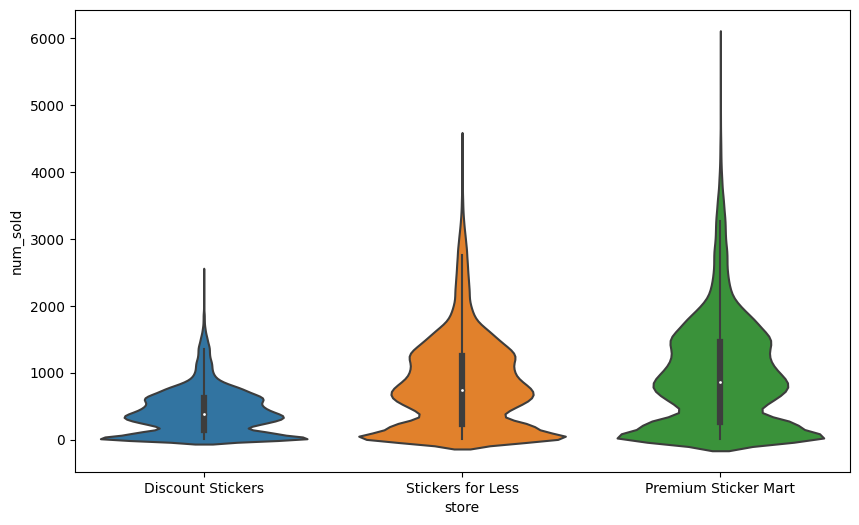

In [15]:
plt.figure(figsize=(10, 6))

sns.violinplot(x='store', y='num_sold', data=train_df, scale='width')

plt.show()

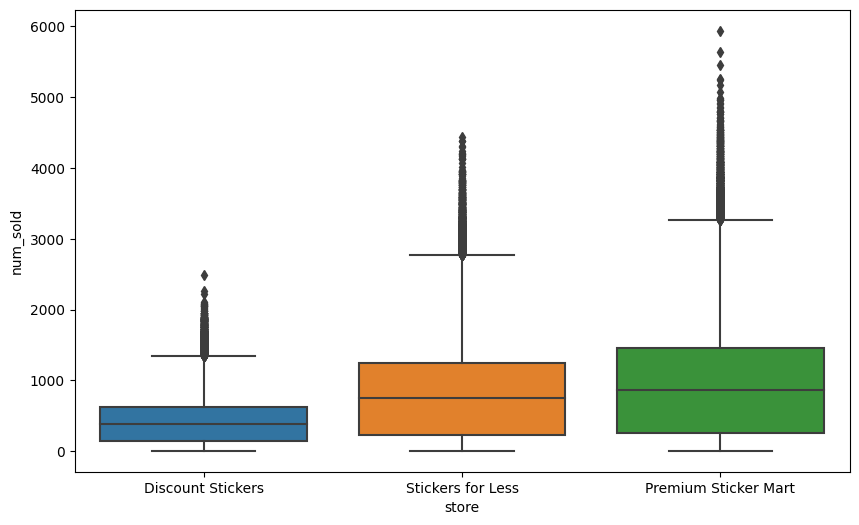

In [16]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='store', y='num_sold', data=train_df)

plt.show()

In [17]:
train_df["product"].value_counts()

product
Holographic Goose     46026
Kaggle                46026
Kaggle Tiers          46026
Kerneler              46026
Kerneler Dark Mode    46026
Name: count, dtype: int64

In [18]:
train_df.groupby('product')['num_sold'].sum()

product
Holographic Goose      7350368.0
Kaggle                56721733.0
Kaggle Tiers          46870306.0
Kerneler              25596840.0
Kerneler Dark Mode    29964209.0
Name: num_sold, dtype: float64

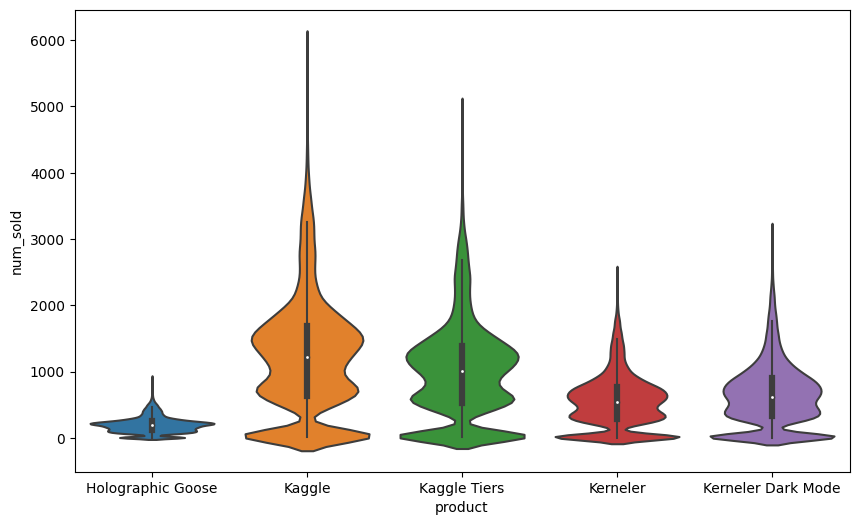

In [19]:
plt.figure(figsize=(10, 6))

sns.violinplot(x='product', y='num_sold', data=train_df, scale='width')

plt.show()

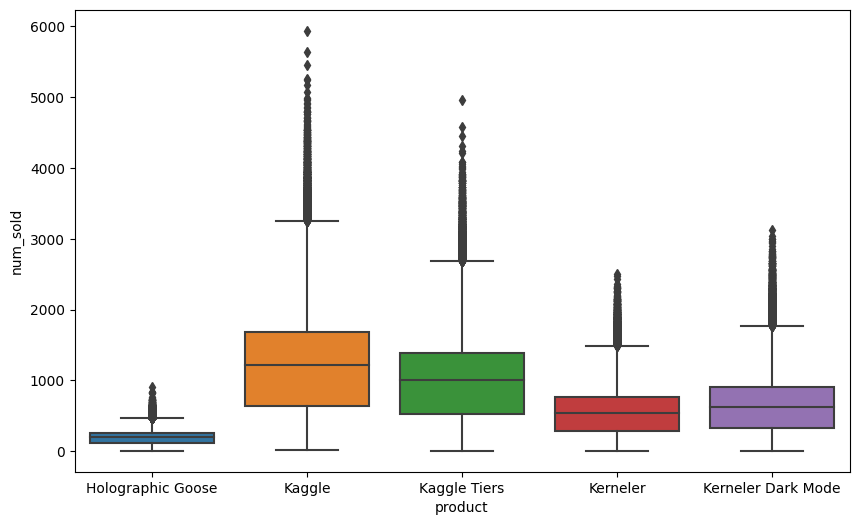

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='product', y='num_sold', data=train_df)

plt.show()

The variables country, store and product are categorical nominal variables.

The variable country has 6 levels, store has 3 levels and product has 5 levels

# NAs

<Axes: xlabel='product', ylabel='country'>

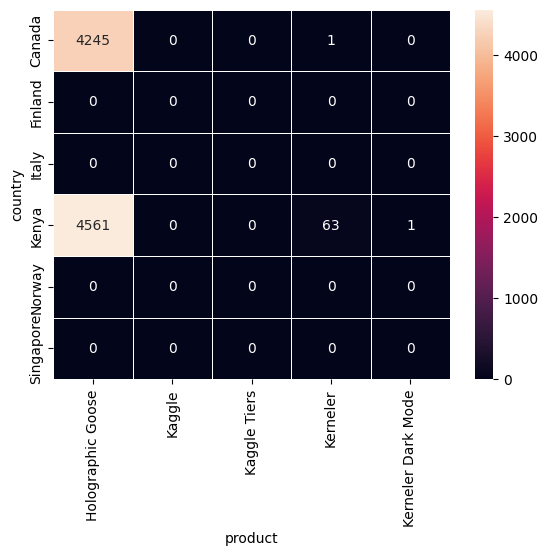

In [21]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['product'],  
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)


<Axes: xlabel='store', ylabel='country'>

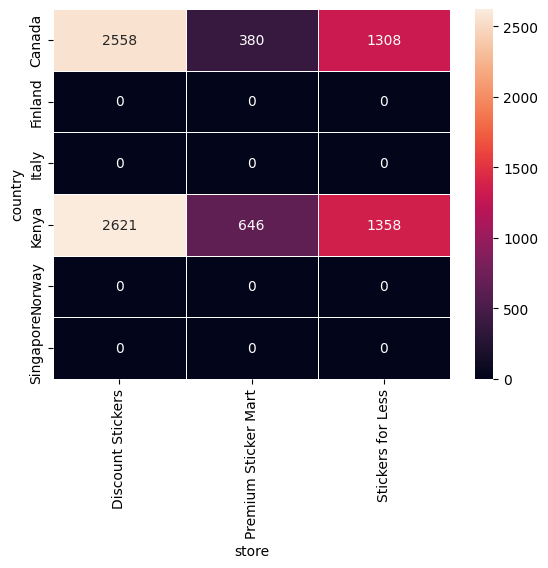

In [22]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['store'],  
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)


<Axes: xlabel='product', ylabel='store'>

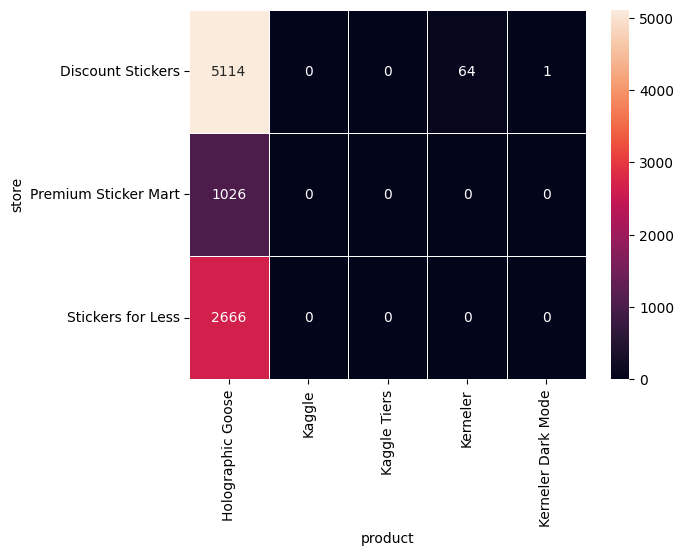

In [23]:
nas_matrix = pd.crosstab(
    index=train_df['store'],
    columns=train_df['product'],  
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)


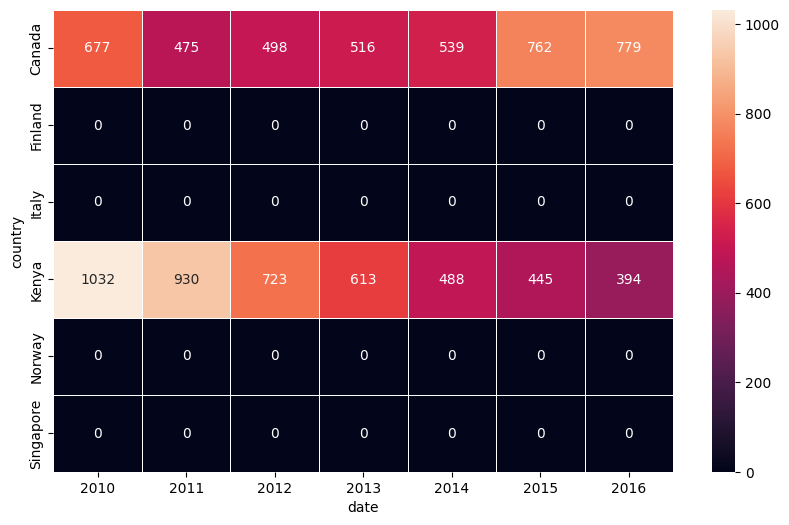

In [24]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['date'].dt.year,
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)
plt.figure(figsize=(10, 6))

sns.heatmap(
    nas_matrix,
    annot=True,
    fmt='g',
    linewidths=0.5,
)
plt.show()

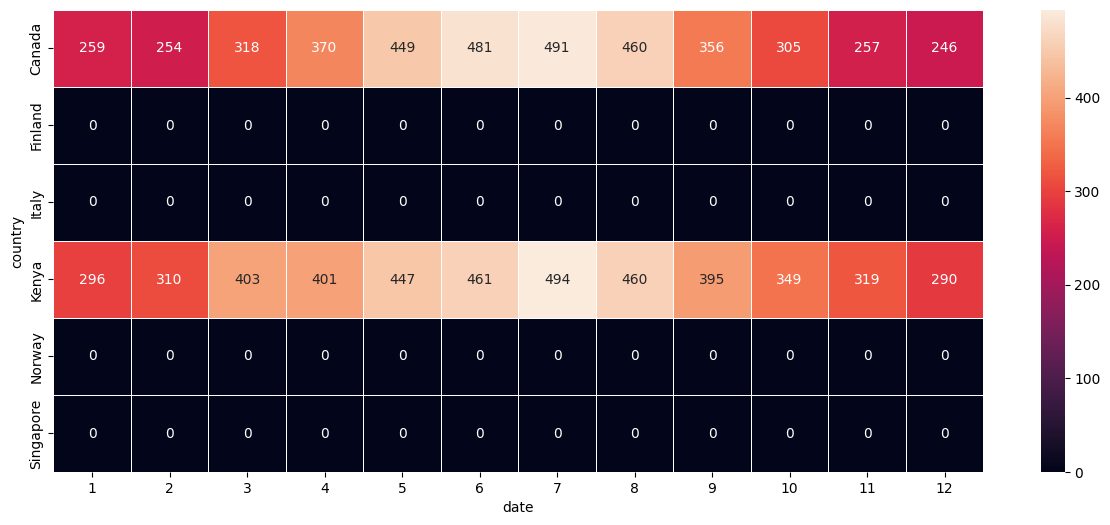

In [25]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['date'].dt.month,
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)
plt.figure(figsize=(15, 6))
sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)
plt.show()

It seems that there is a patron in the data loss Canda and Kenya had lost the same product (holographic goose). The store which had lost more data is Discount Stickers followed by Stickers for Less and Premium Sticker Mart. There also seems to be a patron with year, where first years of data get more lost.

We are going to look closer to Canada and Kenya

In [26]:
df_Canada = train_df[train_df['country']=='Canada'].copy()
df_Kenya = train_df[train_df['country']=='Kenya'].copy()

<Axes: xlabel='product', ylabel='store'>

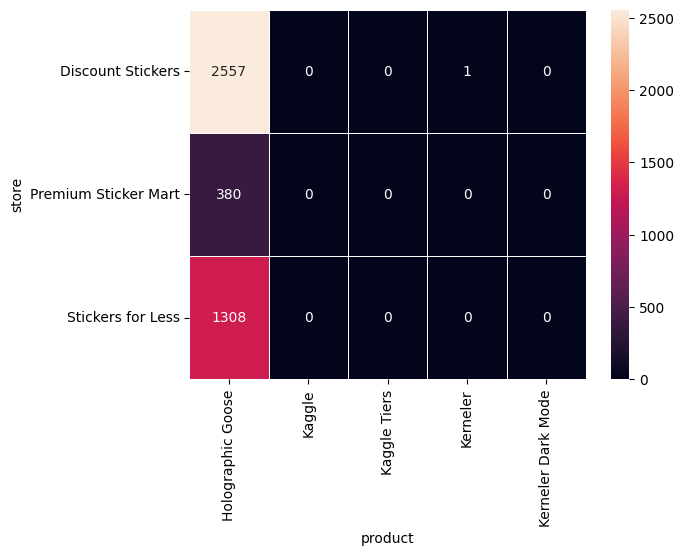

In [27]:
nas_matrix = pd.crosstab(
    index=df_Canada['store'],
    columns=df_Canada['product'],  
    values=df_Canada['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)

<Axes: xlabel='product', ylabel='store'>

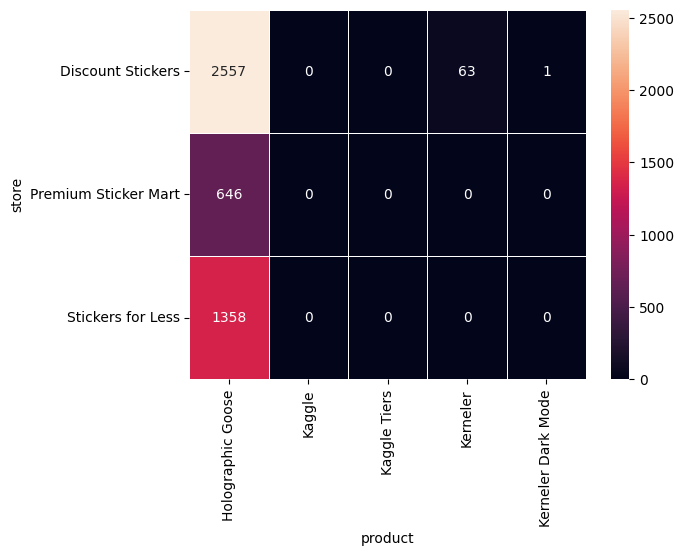

In [28]:
nas_matrix = pd.crosstab(
    index=df_Kenya['store'],
    columns=df_Kenya['product'],  
    values=df_Kenya['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)

In [29]:
group_means = train_df.groupby(['product', 'country','store'])['num_sold'].mean().to_dict()
group_means

{('Holographic Goose', 'Canada', 'Discount Stickers'): nan,
 ('Holographic Goose', 'Canada', 'Premium Sticker Mart'): 248.3821773082223,
 ('Holographic Goose', 'Canada', 'Stickers for Less'): 228.8166533226581,
 ('Holographic Goose', 'Finland', 'Discount Stickers'): 98.00156433320298,
 ('Holographic Goose', 'Finland', 'Premium Sticker Mart'): 235.26046147829487,
 ('Holographic Goose', 'Finland', 'Stickers for Less'): 198.95580758701604,
 ('Holographic Goose', 'Italy', 'Discount Stickers'): 70.84630426280798,
 ('Holographic Goose', 'Italy', 'Premium Sticker Mart'): 170.38287055142746,
 ('Holographic Goose', 'Italy', 'Stickers for Less'): 144.0183809151349,
 ('Holographic Goose', 'Kenya', 'Discount Stickers'): nan,
 ('Holographic Goose', 'Kenya', 'Premium Sticker Mart'): 5.941915227629513,
 ('Holographic Goose', 'Kenya', 'Stickers for Less'): 5.470391993327773,
 ('Holographic Goose', 'Norway', 'Discount Stickers'): 186.7258506061791,
 ('Holographic Goose', 'Norway', 'Premium Sticker Mart

In [30]:
count_grupo = train_df.groupby(['product', 'country','store'])['num_sold'].count().to_dict()
count_grupo

{('Holographic Goose', 'Canada', 'Discount Stickers'): 0,
 ('Holographic Goose', 'Canada', 'Premium Sticker Mart'): 2177,
 ('Holographic Goose', 'Canada', 'Stickers for Less'): 1249,
 ('Holographic Goose', 'Finland', 'Discount Stickers'): 2557,
 ('Holographic Goose', 'Finland', 'Premium Sticker Mart'): 2557,
 ('Holographic Goose', 'Finland', 'Stickers for Less'): 2557,
 ('Holographic Goose', 'Italy', 'Discount Stickers'): 2557,
 ('Holographic Goose', 'Italy', 'Premium Sticker Mart'): 2557,
 ('Holographic Goose', 'Italy', 'Stickers for Less'): 2557,
 ('Holographic Goose', 'Kenya', 'Discount Stickers'): 0,
 ('Holographic Goose', 'Kenya', 'Premium Sticker Mart'): 1911,
 ('Holographic Goose', 'Kenya', 'Stickers for Less'): 1199,
 ('Holographic Goose', 'Norway', 'Discount Stickers'): 2557,
 ('Holographic Goose', 'Norway', 'Premium Sticker Mart'): 2557,
 ('Holographic Goose', 'Norway', 'Stickers for Less'): 2557,
 ('Holographic Goose', 'Singapore', 'Discount Stickers'): 2557,
 ('Holographic 

In [31]:
zero_df = (train_df['num_sold']==0).sum()
zero_df

0

There are two groups with no means. meaning there is no value. Probably the NAs are 0 due to the fact that there is not 0 value. So we are going to imputate with 0

In [32]:
train_df.duplicated().sum()

0

In [33]:
# Solve the NAs problems on X data
train_df_without_na=train_df.fillna(0)

# Outliers

<Axes: ylabel='num_sold'>

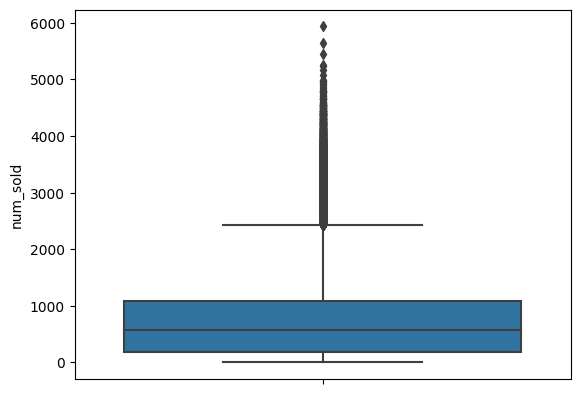

In [34]:
sns.boxplot(data=train_df_without_na, y="num_sold")

# DATA transformation

In [35]:
# See which columns are type categorical and store them
s = (train_df_without_na.dtypes == 'object')
object_cols = list(s[s].index)
print(f"Categorical variables:\n{object_cols}")

Categorical variables:
['country', 'store', 'product']


In [36]:
split_date = '2014-01-02'

data_train = train_df_without_na.copy()
data_train = data_train.sort_values('date')

split_train = data_train[data_train['date'] < split_date]
split_val = data_train[data_train['date'] >= split_date]

In [37]:
from sklearn.model_selection import KFold

def target_encode_group_oof(df, group_cols, target_col, n_splits=5, smoothing=10, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    encoded = pd.Series(index=df.index, dtype=float)
    global_mean = df[target_col].mean()

    for train_idx, val_idx in kf.split(df):
        fold_train = df.iloc[train_idx]

        means = fold_train.groupby(group_cols)[target_col].mean()
        counts = fold_train.groupby(group_cols)[target_col].count()

        smoothed = (means * counts + global_mean * smoothing) / (counts + smoothing)

        val_keys = df.iloc[val_idx][group_cols].apply(tuple, axis=1)
        smoothed_dict = smoothed.to_dict()
        encoded.iloc[val_idx] = val_keys.map(smoothed_dict).values

    return encoded.fillna(global_mean)

X_train_tar = split_train.copy()
X_test_tar = test_df.copy() 
X_val_tar = split_val.copy()


global_mean = X_train_tar['num_sold'].mean()

# Interaction encodings
X_train_tar['country_store_encoded'] = target_encode_group_oof(
    X_train_tar, ['country', 'store'], 'num_sold'
)
X_train_tar['store_product_encoded'] = target_encode_group_oof(
    X_train_tar, ['store', 'product'], 'num_sold'
)
X_train_tar['country_product_encoded'] = target_encode_group_oof(
    X_train_tar, ['country', 'product'], 'num_sold'
)

X_train_tar['country_store_product_encoded'] = target_encode_group_oof(
    X_train_tar, ['country', 'store', 'product'], 'num_sold', smoothing=20 
)
def build_group_encoding_map(df, group_cols, target_col, smoothing, global_mean):
    means = df.groupby(group_cols)[target_col].mean()
    counts = df.groupby(group_cols)[target_col].count()
    return (means * counts + global_mean * smoothing) / (counts + smoothing)

cs_map = build_group_encoding_map(X_train_tar, ['country', 'store'], 'num_sold', 20, global_mean)
sp_map = build_group_encoding_map(X_train_tar, ['store', 'product'], 'num_sold', 20, global_mean)
cp_map = build_group_encoding_map(X_train_tar, ['country', 'product'], 'num_sold', 20, global_mean)
csp_map = build_group_encoding_map(X_train_tar, ['country', 'store', 'product'], 'num_sold', 20, global_mean)

X_test_tar['country_store_encoded'] = X_test_tar[['country', 'store']].apply(tuple, axis=1).map(cs_map).fillna(global_mean)
X_test_tar['store_product_encoded'] = X_test_tar[['store', 'product']].apply(tuple, axis=1).map(sp_map).fillna(global_mean)
X_test_tar['country_product_encoded'] = X_test_tar[['country', 'product']].apply(tuple, axis=1).map(cp_map).fillna(global_mean)
X_test_tar['country_store_product_encoded'] = X_test_tar[['country', 'store', 'product']].apply(tuple, axis=1).map(csp_map).fillna(global_mean)

X_val_tar['country_store_encoded'] = X_val_tar[['country', 'store']].apply(tuple, axis=1).map(cs_map).fillna(global_mean)
X_val_tar['store_product_encoded'] = X_val_tar[['store', 'product']].apply(tuple, axis=1).map(sp_map).fillna(global_mean)
X_val_tar['country_product_encoded'] = X_val_tar[['country', 'product']].apply(tuple, axis=1).map(cp_map).fillna(global_mean)
X_val_tar['country_store_product_encoded'] = X_val_tar[['country', 'store', 'product']].apply(tuple, axis=1).map(csp_map).fillna(global_mean)


In [38]:
from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[('target_enc', TargetEncoder(smooth='auto', target_type='continuous'), object_cols)], remainder='drop')
X_train_tar_v2 = preprocessor.fit_transform(X_train_tar.drop('num_sold', axis=1), X_train_tar['num_sold'])
X_test_tar_v2 = preprocessor.transform(X_test_tar)
X_val_tar_v2 = preprocessor.transform(X_val_tar)


feature_names = preprocessor.get_feature_names_out()

X_train_tar_v2 = pd.DataFrame(
    X_train_tar_v2, 
    columns=feature_names,
    index=X_train_tar.index
).astype(float)

X_test_tar_v2 = pd.DataFrame(
    X_test_tar_v2, 
    columns=feature_names,
    index=X_test_tar.index
).astype(float)

X_val_tar_v2 = pd.DataFrame(
    X_val_tar_v2, 
    columns=feature_names,
    index=X_val_tar.index
).astype(float)

X_train_tar_v2 = X_train_tar_v2.apply(pd.to_numeric)
X_test_tar_v2 = X_test_tar_v2.apply(pd.to_numeric)
X_val_tar_v2 = X_val_tar_v2.apply(pd.to_numeric)

X_train_tarenc = pd.concat([X_train_tar, X_train_tar_v2, split_train.drop(['num_sold', 'id', 'date', 'country',
                                                                                  'store', 'product'], axis=1)], axis=1)
X_test_tarenc = pd.concat([X_test_tar, X_test_tar_v2, test_df.drop(['id', 'date', 'country', 'store', 'product'], axis=1)], axis=1)

X_val_tarenc = pd.concat([X_val_tar, X_val_tar_v2, split_val.drop(['num_sold', 'id', 'date', 'country',
                                                                                  'store', 'product'], axis=1)], axis=1)

print("Train DataFrame shape:", X_train_tarenc.shape)
print("Test DataFrame shape:", X_test_tarenc.shape)
print("Validation DataFrame shape:", X_val_tarenc.shape)


Train DataFrame shape: (131580, 13)
Test DataFrame shape: (98550, 12)
Validation DataFrame shape: (98550, 13)


In [39]:
#Create a new column to differentiate the three dataFrame and join them
X_train_tarenc['df'] = 'train'
X_test_tarenc['df'] = 'test'
X_val_tarenc['df'] = 'val'
df_merged = pd.concat([X_train_tarenc, X_test_tarenc,X_val_tarenc], ignore_index=True)
df_merged = df_merged.reset_index(drop=True)

#add a time-step feature 
df_merged = df_merged.sort_values(['country', 'store', 'product', 'date'])
df_merged['Time'] = df_merged.groupby(['country', 'store', 'product']).cumcount() 

#Use the function create_features to get time features
df_merged = create_features(df_merged)

df_merged.shape

(328680, 22)

In [40]:
# see new dataframe columns
print(f"Dataframe columns:\n{df_merged.columns}")

Dataframe columns:
Index(['id', 'date', 'country', 'store', 'product', 'num_sold',
       'country_store_encoded', 'store_product_encoded',
       'country_product_encoded', 'country_store_product_encoded',
       'target_enc__country', 'target_enc__store', 'target_enc__product', 'df',
       'Time', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear'],
      dtype='object')


In [41]:
# set variable y and x for the training data
df_merged=df_merged.sort_values(by='id')
y_train = df_merged[df_merged['df']=='train'].num_sold
y_val = df_merged[df_merged['df']=='val'].num_sold
df_x = df_merged.drop('num_sold', axis=1).copy()

In [42]:
#Transforming the categorical variables from the test and training data into numerical
import sklearn
from sklearn.preprocessing import OneHotEncoder
OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, feature_name_combiner='concat')
OH_array  = OH_encoder.fit_transform(df_x[object_cols])
OH_cols_df = pd.DataFrame(OH_array, columns=OH_encoder.get_feature_names_out(object_cols), index=df_x.index
)
OH_cols_df

,country_Canada,country_Finland,country_Italy,country_Kenya,country_Norway,country_Singapore,store_Discount Stickers,store_Premium Sticker Mart,store_Stickers for Less,product_Holographic Goose,product_Kaggle,product_Kaggle Tiers,product_Kerneler,product_Kerneler Dark Mode
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
64,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
63,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
62,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
61,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230125,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
230126,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
230127,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
230128,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [43]:
#Merge the categorical variables with the other variables
OH_cols_df.index = df_x.index

num_x_df = df_x.drop(object_cols, axis=1)

OH_x_df = pd.concat([num_x_df, OH_cols_df], axis=1)

OH_x_df.columns = OH_x_df.columns.astype(str)

OH_x_df.columns

Index(['id', 'date', 'country_store_encoded', 'store_product_encoded',
       'country_product_encoded', 'country_store_product_encoded',
       'target_enc__country', 'target_enc__store', 'target_enc__product', 'df',
       'Time', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear', 'country_Canada', 'country_Finland',
       'country_Italy', 'country_Kenya', 'country_Norway', 'country_Singapore',
       'store_Discount Stickers', 'store_Premium Sticker Mart',
       'store_Stickers for Less', 'product_Holographic Goose',
       'product_Kaggle', 'product_Kaggle Tiers', 'product_Kerneler',
       'product_Kerneler Dark Mode'],
      dtype='object')

In [44]:
#Make sure there isn't no NAs
print(f"NAs num_sold: {y_train.isnull().sum()} \n\n NAs varialbes: \n{OH_x_df.isnull().sum()}")


NAs num_sold: 0 

 NAs varialbes: 
id                               0
date                             0
country_store_encoded            0
store_product_encoded            0
country_product_encoded          0
country_store_product_encoded    0
target_enc__country              0
target_enc__store                0
target_enc__product              0
df                               0
Time                             0
dayofweek                        0
quarter                          0
month                            0
year                             0
dayofyear                        0
dayofmonth                       0
weekofyear                       0
country_Canada                   0
country_Finland                  0
country_Italy                    0
country_Kenya                    0
country_Norway                   0
country_Singapore                0
store_Discount Stickers          0
store_Premium Sticker Mart       0
store_Stickers for Less          0
product_Holographic 

In [45]:
#Separate the test data and training data
X_train = OH_x_df[OH_x_df['df']=='train'].drop(['id', 'df', 'date'], axis=1).copy()
X_test = OH_x_df[OH_x_df['df']=='test'].drop(['id', 'df', 'date'], axis=1).copy()
X_val = OH_x_df[OH_x_df['df']=='val'].drop(['id', 'df', 'date'], axis=1).copy()

In [46]:
import joblib
import json
import optuna
import optuna.visualization as vis
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error, root_mean_squared_error,
    root_mean_squared_log_error
)
from sklearn.model_selection import cross_val_score, learning_curve, TimeSeriesSplit
from optuna.pruners import MedianPruner
from functools import partial

# Kaggle directory for saving files
Output_directory= '/kaggle/working/'

# Save dataframes
X_train.to_parquet(f'{Output_directory}X_train.parquet')
X_test.to_parquet(f'{Output_directory}X_test.parquet')
X_val.to_parquet(f'{Output_directory}X_val.parquet')
y_train.to_frame(name='sales').to_parquet(f'{Output_directory}y_train.parquet')
y_val.to_frame(name='sales').to_parquet(f'{Output_directory}y_val.parquet')

# Time-based validation: respects chronological order, never validates on data prior to that fold's train set
tscv = TimeSeriesSplit(n_splits=5)

# Pruner
pruner = MedianPruner(
    n_startup_trials=8,
    n_warmup_steps=2,
    interval_steps=1,
    n_min_trials=8,
)

# Early stopping: stops the whole study if the best value hasn't improved in the last `patience` trials
def early_stopping(study, trial, patience=30, start_trial_number=0):
    trials_since_start = trial.number - start_trial_number
    if trials_since_start < patience:
        return

    best_trial_number = study.best_trial.number
    if best_trial_number < start_trial_number:
        trials_without_improvement = trials_since_start
    else:
        trials_without_improvement = trial.number - best_trial_number

    if trials_without_improvement >= patience:
        print(f"No improvement in the last {patience} trials. Stopping study.")
        study.stop()
#Sampler with seed for every model
sampler= optuna.samplers.TPESampler(seed=42)

#####################################################################
# METRICS
#####################################################################

def cross_val(model, X_train, y_train, name=""):
    scores = -cross_val_score(model, X_train, y_train, cv=tscv, scoring='neg_root_mean_squared_error')
    print(f"--- {name}: Cross-validation (5 folds) ---")
    print(f"RMSE por fold: {np.round(scores, 4)}")
    print(f"Media: {scores.mean():.4f} | Std: {scores.std():.4f} | CV%: {scores.std()/scores.mean()*100:.2f}%")
    return {'cv_mean': scores.mean(), 'cv_std': scores.std()}

def plot_learning_curve(model, X_train, y_train, name=""):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train, cv=tscv,
        scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
    )
    train_rmse = -train_scores.mean(axis=1)
    val_rmse = -val_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_rmse, 'o-', label='Train RMSE')
    plt.plot(train_sizes, val_rmse, 'o-', label='Val RMSE')
    plt.xlabel('Training set size')
    plt.ylabel('RMSE')
    plt.title(f'Learning Curve - {name}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def evaluate_additional_metrics(y_true, y_pred, name=""):
    errors = y_true - y_pred
    error_pct = np.abs(errors / y_true) * 100

    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape_val = mean_absolute_percentage_error(y_true, y_pred) * 100
    try:
        rmsle = root_mean_squared_log_error(y_true, y_pred)
    except ValueError:
        rmsle = None  # fails if there are negative predictions

    print(f"--- {name}: Additional metrics ---")
    print(f"MAE: {mae:.4f} | MAPE: {mape_val:.2f}% | R²: {r2:.4f}", end="")
    print(f" | RMSLE: {rmsle:.4f}" if rmsle is not None else " | RMSLE: N/A (negative predictions)")
    print(f"Bias (mean error): {errors.mean():.4f}")
    print(f"Prediction std: {y_pred.std():.4f} | Real std: {y_true.std():.4f}")
    for tol in [10, 15, 20]:
        successes = (error_pct <= tol).mean() * 100
        print(f"Within ±{tol}%: {successes:.2f}%")
        
def evaluate_gap(y_train, pred_train, y_val, pred_val, name=""):
    rmse_train = root_mean_squared_error(y_train, pred_train)
    rmse_val = root_mean_squared_error(y_val, pred_val)
    gap = rmse_val - rmse_train
    gap_pct = gap / rmse_train * 100

    print(f"--- {name}: Train vs Val ---")
    print(f"RMSE train: {rmse_train:.4f} | RMSE val: {rmse_val:.4f}")
    print(f"Gap: {gap:.4f} ({gap_pct:.2f}%)")

    return {'rmse_train': rmse_train, 'rmse_val': rmse_val, 'gap_pct': gap_pct}


In [47]:
##############################################################
# 1. XGBoost
##############################################################
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 80),
        'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.15, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.2, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 50.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

#study_xgb = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
#study_xgb.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
#print(f"XGBoost best parameters: {study_xgb.best_params}")

# saves the study
#joblib.dump(study_xgb, f'{Output_directory}study_xgb.pkl')

#Load study 
study_xgb = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb (1).pkl')

In [48]:
print(f"Trials executed: {len(study_xgb.trials)}")
print(f"Best trial: {study_xgb.best_trial.number}")
print(f"Best RMSE: {study_xgb.best_value:.4f}")
print(f"Best parameters: {study_xgb.best_params}")

Trials executed: 130
Best trial: 69
Best RMSE: 116.9689
Best parameters: {'n_estimators': 1533, 'learning_rate': 0.25214825742156066, 'max_depth': 8, 'min_child_weight': 48, 'gamma': 0.11085187011214934, 'subsample': 0.9210747818606573, 'colsample_bytree': 0.3750908743558959, 'colsample_bylevel': 0.2623555525202323, 'reg_alpha': 1.3739706071502693e-08, 'reg_lambda': 0.00039484452627145}


In [49]:
df_trials_xgb = study_xgb.trials_dataframe()
print(df_trials_xgb[['number', 'value','state']].tail(15))

     number       value     state
115     115  123.295722  COMPLETE
116     116  148.606400    PRUNED
117     117  123.906975  COMPLETE
118     118  148.114352    PRUNED
119     119  166.719151    PRUNED
120     120  117.936038  COMPLETE
121     121  170.303032    PRUNED
122     122  122.051423  COMPLETE
123     123  120.947199  COMPLETE
124     124  147.972954    PRUNED
125     125  121.658221  COMPLETE
126     126  143.156459    PRUNED
127     127  145.715766    PRUNED
128     128  146.598028    PRUNED
129     129  148.115075    PRUNED


In [50]:
vis.plot_optimization_history(study_xgb).show()
vis.plot_param_importances(study_xgb).show()

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning:

invalid value encountered in less



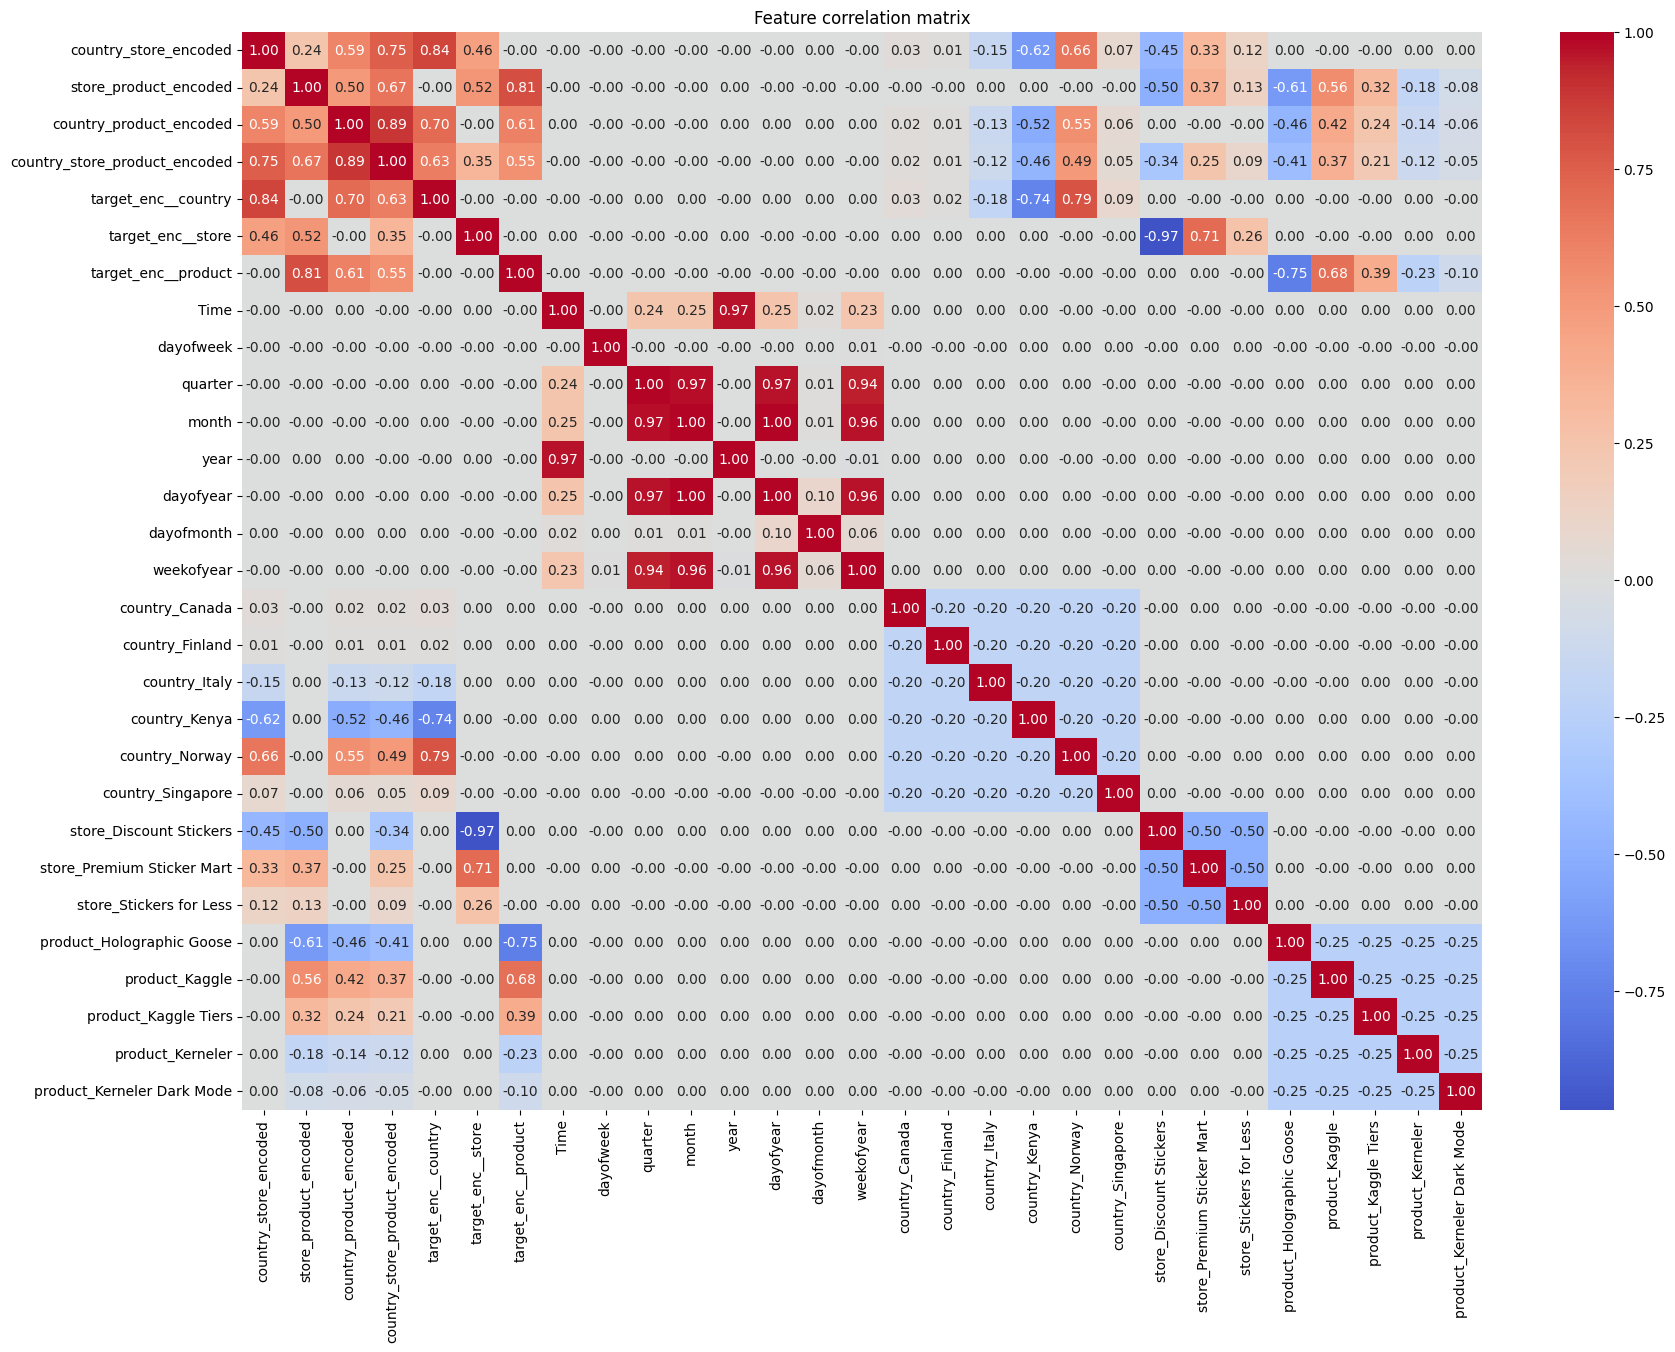

In [51]:
# Autocorrelation matrix
corr_matrix = X_train.corr()

plt.figure(figsize=(20, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,  fmt='.2f', annot=True)
plt.title('Feature correlation matrix')
plt.show()


In [52]:
#model_xgb = xgb.XGBRegressor(**study_xgb.best_params, random_state=42)
#model_xgb.fit(X_train, y_train)
#joblib.dump(model_xgb, f'{Output_directory}model_xgb.pkl')

#Load study 
model_xgb = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb.pkl')

--- XGBoost: Train vs Val ---
RMSE train: 59.7597 | RMSE val: 238.6063
Gap: 178.8465 (299.28%)
--- XGBoost: Additional metrics ---
MAE: 128.1429 | MAPE: 731068917916628864.00% | R²: 0.8618 | RMSLE: N/A (negative predictions)
Bias (mean error): -113.8687
Prediction std: 780.9919 | Real std: 641.8150
Within ±10%: 32.56%
Within ±15%: 45.34%
Within ±20%: 56.19%
--- XGBoost: Cross-validation (5 folds) ---
RMSE por fold: [166.6069 110.1116 139.6916 101.3295 111.1455]
Media: 125.7770 | Std: 24.1572 | CV%: 19.21%


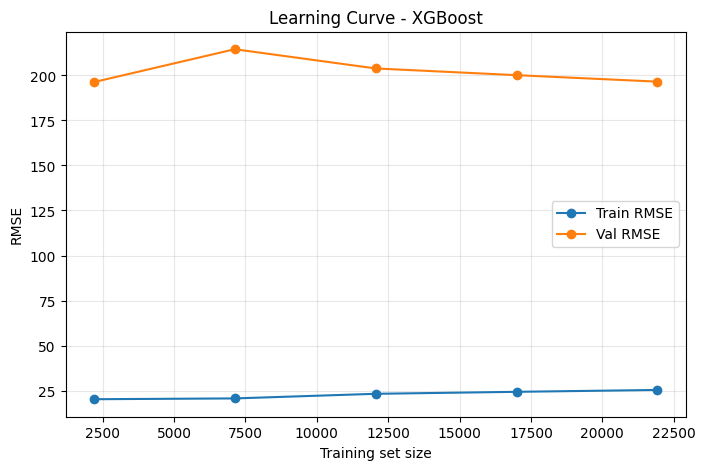

In [53]:
pred_train_xgb = model_xgb.predict(X_train)
pred_val_xgb = model_xgb.predict(X_val)
gap_xgb = evaluate_gap(y_train, pred_train_xgb, y_val, pred_val_xgb, "XGBoost")
addmet_xgb_trget = evaluate_additional_metrics(y_val, pred_val_xgb, "XGBoost")
cv_xgb = cross_val(model_xgb, X_train, y_train, "XGBoost")
plot_learning_curve(model_xgb, X_train, y_train, "XGBoost")


In [54]:
from sklearn.inspection import permutation_importance

#perm = permutation_importance(model_xgb, X_val, y_val, random_state=42, n_repeats=10)
#Load study 
perm = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result.pkl')
feature_importances = pd.DataFrame({
    'feature': X_val.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values(by='importance_mean', ascending=False)

#joblib.dump(perm, f'{Output_directory}permutation_result.pkl')

print(feature_importances)

                          feature  importance_mean  importance_std
0           country_store_encoded         0.168907        0.001805
2         country_product_encoded         0.100695        0.000514
6             target_enc__product         0.047059        0.000667
8                       dayofweek         0.031806        0.000698
18                  country_Kenya         0.011416        0.000476
14                     weekofyear         0.011273        0.000183
10                          month         0.009455        0.000111
9                         quarter         0.005638        0.000112
12                      dayofyear         0.005282        0.000269
25                 product_Kaggle         0.002968        0.000356
23        store_Stickers for Less         0.002601        0.000043
28     product_Kerneler Dark Mode         0.002266        0.000038
26           product_Kaggle Tiers         0.001502        0.000052
24      product_Holographic Goose         0.001458        0.00

In [55]:
import shap

SAMPLE_SIZE = 5000
X_train_sample = X_train.sample(n=SAMPLE_SIZE, random_state=42)

explainer_lgb = shap.TreeExplainer(model_xgb)
shap_values_lgb = explainer_lgb.shap_values(X_train_sample, check_additivity=False)

shap_lgb = pd.DataFrame({
    'feature': X_train_sample.columns,
    'mean_abs_shap': np.abs(shap_values_lgb).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_lgb['pct'] = shap_lgb['mean_abs_shap'] / shap_lgb['mean_abs_shap'].sum() * 100

print(shap_lgb)

# Flag features below a threshold as candidates for removal
UMBRAL_PCT = 0.5  # adjust as needed

candidatas_a_eliminar = shap_lgb[shap_lgb['pct'] < UMBRAL_PCT]['feature'].tolist()
print(f"\nCandidate features to drop (< {UMBRAL_PCT}% of total importance):")
print(candidatas_a_eliminar)

                          feature  mean_abs_shap        pct
0         country_product_encoded     206.396347  20.341387
1           country_store_encoded     186.848236  18.414824
2             target_enc__product     117.352737  11.565697
3                   country_Kenya      59.436512   5.857764
4               target_enc__store      55.557156   5.475434
5                       dayofweek      48.642086   4.793920
6       product_Holographic Goose      36.118233   3.559632
7           store_product_encoded      35.956268   3.543669
8   country_store_product_encoded      34.004612   3.351324
9                            Time      29.704006   2.927478
10                 product_Kaggle      26.293316   2.591337
11     store_Premium Sticker Mart      24.145361   2.379645
12                 country_Norway      23.259636   2.292353
13        store_Discount Stickers      17.723637   1.746753
14                           year      11.929787   1.175740
15                  country_Italy      1

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

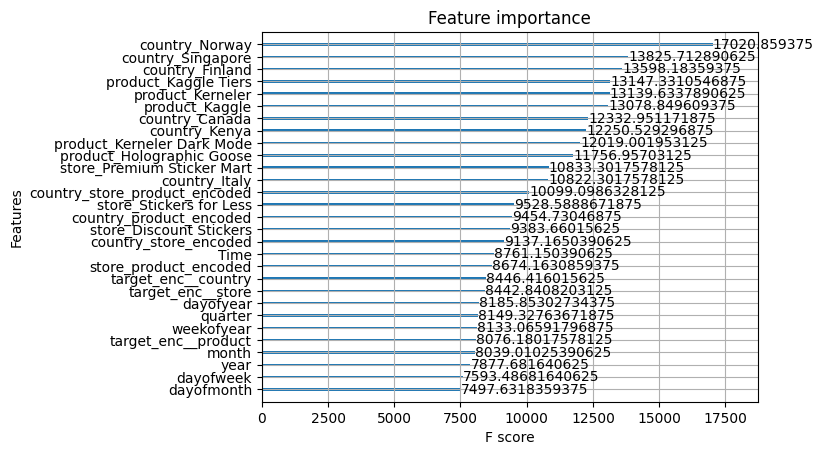

In [56]:
xgb.plot_importance(model_xgb, importance_type='cover')

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

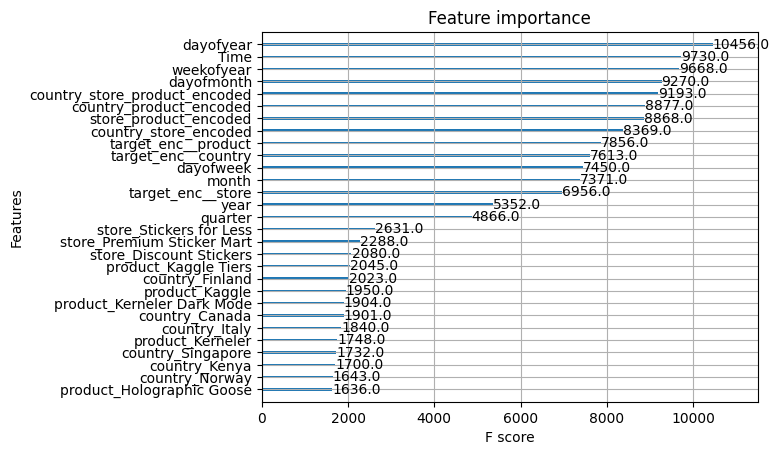

In [57]:
xgb.plot_importance(model_xgb, importance_type='weight')

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

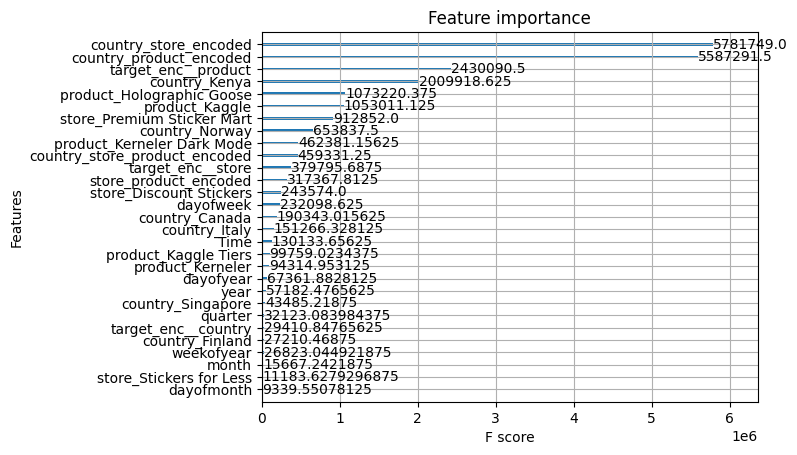

In [58]:
xgb.plot_importance(model_xgb, importance_type='gain')

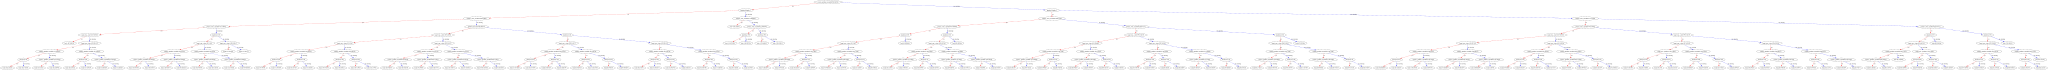

In [59]:
xgb.to_graphviz(model_xgb, num_trees=0)

In [60]:
#Target encoded dataframe
X_train_target = X_train.drop(['country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()

X_val_target = X_val.drop(['country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()

In [61]:
# 1. XGBoost with only target encoding 
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 80),
        'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.15, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.2, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 50.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_target)):
        X_tr, X_va = X_train_target.iloc[train_idx], X_train_target.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

#study_xgb_target = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
#study_xgb_target.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
#print(f"XGBoost best parameters: {study_xgb_target.best_params}")

# saves the study
#joblib.dump(study_xgb_target, f'{Output_directory}study_xgb_target.pkl')

#Load study 
study_xgb_target = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb_target.pkl')

In [62]:
print(f"Trials executed: {len(study_xgb_target.trials)}")
print(f"Best trial: {study_xgb_target.best_trial.number}")
print(f"Best RMSE: {study_xgb_target.best_value:.4f}")
print(f"Best parameters: {study_xgb_target.best_params}")

Trials executed: 188
Best trial: 127
Best RMSE: 119.2248
Best parameters: {'n_estimators': 998, 'learning_rate': 0.10706318167142384, 'max_depth': 10, 'min_child_weight': 70, 'gamma': 1.3605226775164701e-05, 'subsample': 0.5485329383888901, 'colsample_bytree': 0.1541294784773671, 'colsample_bylevel': 0.8876055346377396, 'reg_alpha': 0.0003226270488591151, 'reg_lambda': 2.9056907770639593}


In [63]:
model_xgb_target = xgb.XGBRegressor(**study_xgb_target.best_params, random_state=42)
model_xgb_target.fit(X_train_target, y_train)
joblib.dump(model_xgb_target, f'{Output_directory}model_xgb_target.pkl')

#Load study 
#model_xgb_target = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb.pkl')

['/kaggle/working/model_xgb_target.pkl']

--- XGBoost: Train vs Val ---
RMSE train: 59.4411 | RMSE val: 238.8551
Gap: 179.4140 (301.83%)
--- XGBoost: Additional metrics ---
MAE: 136.0334 | MAPE: 1134353936364622848.00% | R²: 0.8615 | RMSLE: N/A (negative predictions)
Bias (mean error): -108.1363
Prediction std: 788.9924 | Real std: 641.8150
Within ±10%: 31.73%
Within ±15%: 44.01%
Within ±20%: 53.46%
--- XGBoost: Cross-validation (5 folds) ---
RMSE por fold: [169.8364 111.6775 144.913   90.9797  97.3442]
Media: 122.9502 | Std: 29.9517 | CV%: 24.36%


A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.


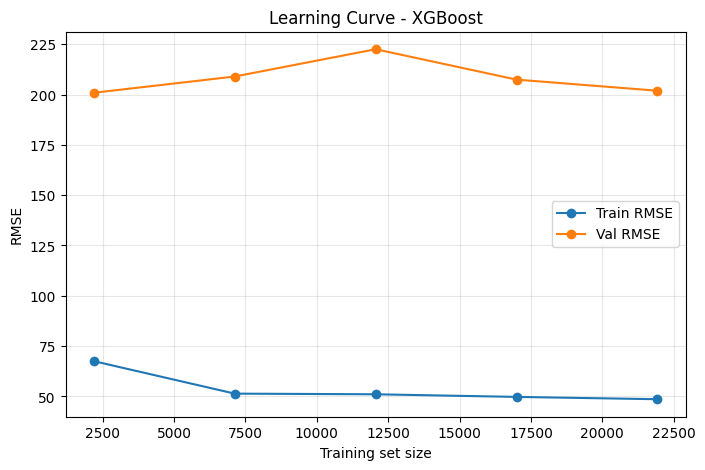

In [64]:
pred_train_xgb_target = model_xgb_target.predict(X_train_target)
pred_val_xgb_target = model_xgb_target.predict(X_val_target)
gap_xgb_target = evaluate_gap(y_train, pred_train_xgb_target, y_val, pred_val_xgb_target, "XGBoost")
addmet_xgb_target = evaluate_additional_metrics(y_val, pred_val_xgb_target, "XGBoost")
cv_xgb = cross_val(model_xgb_target, X_train_target, y_train, "XGBoost")
plot_learning_curve(model_xgb_target, X_train_target, y_train, "XGBoost")


In [65]:
perm_xgb_target = permutation_importance(model_xgb_target, X_val_target, y_val, random_state=42, n_repeats=10)
#Load study 
#perm_xgb_target= joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result.pkl')
feature_importances = pd.DataFrame({
    'feature': X_val_target.columns,
    'importance_mean': perm_xgb_target.importances_mean,
    'importance_std': perm_xgb_target.importances_std
}).sort_values(by='importance_mean', ascending=False)

joblib.dump(perm_xgb_target, f'{Output_directory}permutation_result_xgb_target.pkl')

print(feature_importances)

                          feature  importance_mean  importance_std
2         country_product_encoded         0.220480        0.000934
8                       dayofweek         0.027559        0.000556
3   country_store_product_encoded         0.022386        0.000543
1           store_product_encoded         0.016194        0.000522
0           country_store_encoded         0.013249        0.000426
5               target_enc__store         0.009565        0.000455
6             target_enc__product         0.005453        0.000277
12                      dayofyear         0.005232        0.000193
14                     weekofyear         0.005046        0.000110
9                         quarter         0.001042        0.000035
10                          month         0.000674        0.000090
13                     dayofmonth         0.000492        0.000065
7                            Time         0.000000        0.000000
11                           year         0.000000        0.00

In [66]:
#Onehot encoding dataframe
X_train_onehot = X_train.drop(['target_enc__store',
                                                  'target_enc__country', 'target_enc__product','country_store_encoded', 'store_product_encoded',
                                                  'country_product_encoded', 'country_store_product_encoded'], axis=1).copy()


X_val_onehot = X_val.drop(['target_enc__store',
                           'target_enc__country', 'target_enc__product','country_store_encoded', 'store_product_encoded',
                           'country_product_encoded', 'country_store_product_encoded'], axis=1).copy()

In [67]:
# 1. XGBoost with only onehot encoding
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 80),
        'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.15, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.2, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 50.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_onehot)):
        X_tr, X_va = X_train_onehot.iloc[train_idx], X_train_onehot.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

#study_xgb_onehot = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
#study_xgb_onehot.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
#print(f"XGBoost best parameters: {study_xgb_onehot.best_params}")

# saves the study
#joblib.dump(study_xgb_onehot, f'{Output_directory}study_xgb_onehot.pkl')
#Load study 
study_xgb_onehot = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb_onehot.pkl')

In [68]:
print(f"Trials executed: {len(study_xgb_onehot.trials)}")
print(f"Best trial: {study_xgb_onehot.best_trial.number}")
print(f"Best RMSE: {study_xgb_onehot.best_value:.4f}")
print(f"Best parameters: {study_xgb_onehot.best_params}")

Trials executed: 141
Best trial: 80
Best RMSE: 123.0016
Best parameters: {'n_estimators': 2730, 'learning_rate': 0.019072003765976762, 'max_depth': 9, 'min_child_weight': 8, 'gamma': 0.0006940010936455361, 'subsample': 0.9541790515334193, 'colsample_bytree': 0.7353710415390853, 'colsample_bylevel': 0.2635718387597834, 'reg_alpha': 5.941798125401254e-07, 'reg_lambda': 2.101920145294039e-06}


In [69]:
model_xgb_onehot = xgb.XGBRegressor(**study_xgb_onehot.best_params, random_state=42)
model_xgb_onehot.fit(X_train_onehot, y_train)
joblib.dump(model_xgb_onehot, f'{Output_directory}model_xgb_onehot.pkl')

#Load study 
#model_xgb_onehot = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb.pkl')

['/kaggle/working/model_xgb_onehot.pkl']

--- XGBoost: Train vs Val ---
RMSE train: 45.5395 | RMSE val: 237.1749
Gap: 191.6354 (420.81%)
--- XGBoost: Additional metrics ---
MAE: 126.8496 | MAPE: 680543953897457920.00% | R²: 0.8634 | RMSLE: N/A (negative predictions)
Bias (mean error): -116.6153
Prediction std: 781.8034 | Real std: 641.8150
Within ±10%: 34.75%
Within ±15%: 48.65%
Within ±20%: 60.65%
--- XGBoost: Cross-validation (5 folds) ---
RMSE por fold: [158.3633 120.3125 142.7629  96.1993  97.3701]
Media: 123.0016 | Std: 24.5908 | CV%: 19.99%


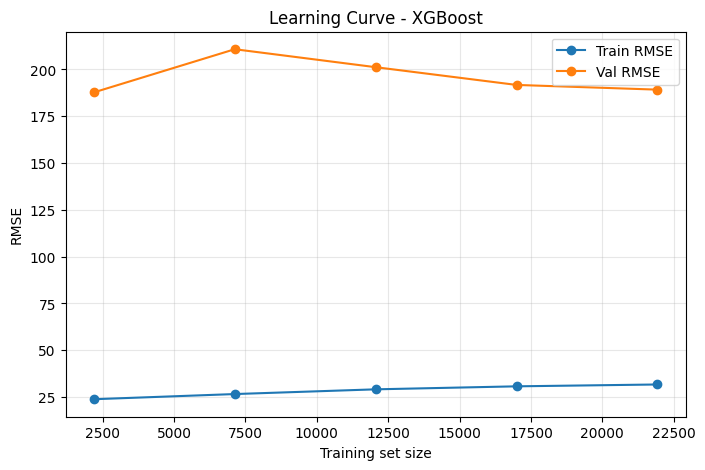

In [70]:
pred_train_xgb_onehot = model_xgb_onehot.predict(X_train_onehot)
pred_val_xgb_onehot = model_xgb_onehot.predict(X_val_onehot)
gap_xgb_onehot = evaluate_gap(y_train, pred_train_xgb_onehot, y_val, pred_val_xgb_onehot, "XGBoost")
addmet_xgb_onehot = evaluate_additional_metrics(y_val, pred_val_xgb_onehot, "XGBoost")
cv_xgb_onehot = cross_val(model_xgb_onehot, X_train_onehot, y_train, "XGBoost")
plot_learning_curve(model_xgb_onehot, X_train_onehot, y_train, "XGBoost")


In [71]:
perm_xgb_onehot = permutation_importance(model_xgb_onehot, X_val_onehot, y_val, random_state=42, n_repeats=10)
#Load study 
#perm = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result.pkl')
feature_importances= pd.DataFrame({
    'feature': X_val_onehot.columns,
    'importance_mean': perm_xgb_onehot.importances_mean,
    'importance_std': perm_xgb_onehot.importances_std
}).sort_values(by='importance_mean', ascending=False)

joblib.dump(perm_xgb_onehot, f'{Output_directory}permutation_result_xgb_onehot.pkl')

print(feature_importances)

                       feature  importance_mean  importance_std
11               country_Kenya         0.415953        0.002039
12              country_Norway         0.372695        0.002844
17   product_Holographic Goose         0.326531        0.001284
18              product_Kaggle         0.200420        0.001582
14     store_Discount Stickers         0.167040        0.001808
15  store_Premium Sticker Mart         0.067475        0.001431
19        product_Kaggle Tiers         0.051517        0.000873
20            product_Kerneler         0.037805        0.000543
1                    dayofweek         0.031096        0.000779
10               country_Italy         0.027562        0.000427
21  product_Kerneler Dark Mode         0.012188        0.000223
13           country_Singapore         0.010510        0.000143
7                   weekofyear         0.009229        0.000092
5                    dayofyear         0.006983        0.000176
3                        month         0